<a href="https://colab.research.google.com/github/Mezo-555/AI_Platforms_Assignments/blob/main/Ai_Platforms_Ass4_Part1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# CNN with Tensorflow|Keras for Fashion MNIST

In [1]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.datasets import fashion_mnist
from tensorflow.keras.utils import to_categorical
import numpy as np
import matplotlib.pyplot as plt

In [2]:
# --- 1. Load and Preprocess Data ---
print("Loading Fashion MNIST dataset...")
(x_train, y_train), (x_test, y_test) = fashion_mnist.load_data()

# Normalize pixel values to be between 0 and 1
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# Reshape data to include channel dimension (1 for grayscale)
# CNNs expect (batch_size, height, width, channels)
x_train = x_train.reshape((x_train.shape[0], 28, 28, 1))
x_test = x_test.reshape((x_test.shape[0], 28, 28, 1))

# One-hot encode the labels
y_train_one_hot = to_categorical(y_train, 10)
y_test_one_hot = to_categorical(y_test, 10)

# Define class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

print(f"x_train shape: {x_train.shape}")
print(f"y_train_one_hot shape: {y_train_one_hot.shape}")
print(f"x_test shape: {x_test.shape}")
print(f"y_test_one_hot shape: {y_test_one_hot.shape}")

Loading Fashion MNIST dataset...
29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
x_train shape: (60000, 28, 28, 1)
y_train_one_hot shape: (60000, 10)
x_test shape: (10000, 28, 28, 1)
y_test_one_hot shape: (10000, 10)


In [3]:
# --- 2. Build the CNN Model ---
print("Building the CNN model...")

model = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(28, 28, 1)),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation='relu', padding='same'),
    MaxPooling2D((2, 2)),

    # Flatten the output to feed into Dense layers
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    Dropout(0.5),  # Dropout for regularization

    # Output layer
    Dense(10, activation='softmax')  # 10 classes, softmax for probability distribution
])

# Print model summary
model.summary()

Building the CNN model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 421,642 (1.61 MB)

 Trainable params: 421,642 (1.61 MB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# --- 3. Compile the Model ---
print("Compiling the model...")
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

Compiling the model...


In [5]:
# --- 4. Train the Model ---
print("Training the model...")
epochs = 20
batch_size = 64

# Store the training history
history = model.fit(
    x_train,
    y_train_one_hot,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_test, y_test_one_hot)
)

print("Training finished.")

Training the model...
Epoch 1/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.7288 - loss: 0.7573 - val_accuracy: 0.8760 - val_loss: 0.3440
Epoch 2/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8697 - loss: 0.3645 - val_accuracy: 0.8952 - val_loss: 0.2915
Epoch 3/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8891 - loss: 0.3116 - val_accuracy: 0.9001 - val_loss: 0.2728
Epoch 4/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9009 - loss: 0.2753 - val_accuracy: 0.9065 - val_loss: 0.2606
Epoch 5/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9096 - loss: 0.2507 - val_accuracy: 0.9131 - val_loss: 0.2463
Epoch 6/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.9153 - loss: 0.2314 - val_accuracy: 0.9171 - val_loss: 0.2310
Epoch 7/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9243 - loss: 0.2075 - val_accuracy: 0.9206 - val_loss: 0.2259
Epoch 8/20
938/938 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.9286 - loss: 0.

In [6]:
# --- 5. Evaluate the Model ---
print("Evaluating the model on test data...")
test_loss, test_acc = model.evaluate(x_test, y_test_one_hot, verbose=2)
print(f'\nTest accuracy: {test_acc:.4f}')
print(f'Test loss: {test_loss:.4f}')

Evaluating the model on test data...
313/313 - 1s - 3ms/step - accuracy: 0.9221 - loss: 0.2634

Test accuracy: 0.9221
Test loss: 0.2634


Plotting training history...


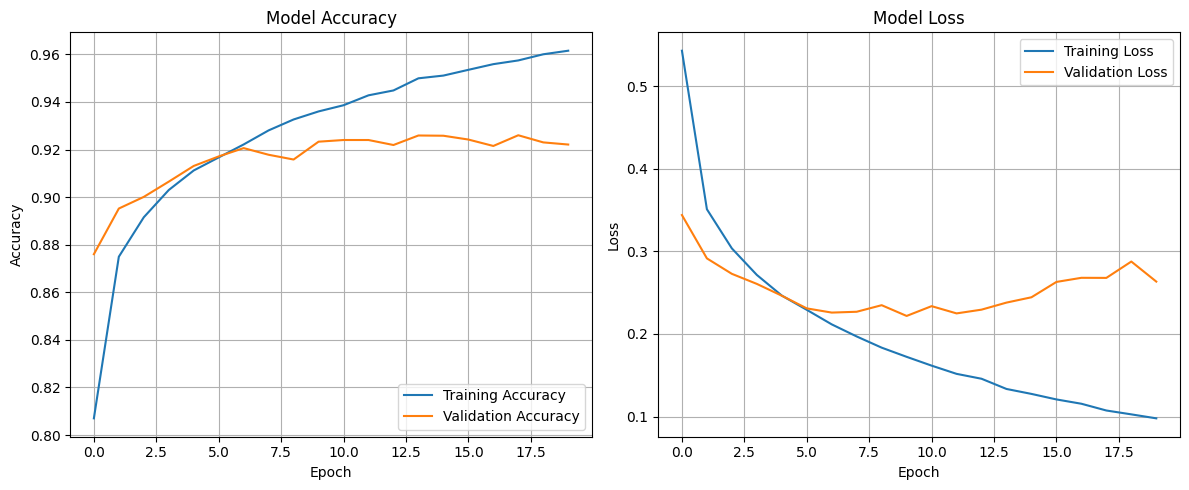

In [7]:
# --- 6. Visualize Training History ---
print("Plotting training history...")

# Create a figure for the plots
plt.figure(figsize=(12, 5))

# Plot training & validation accuracy
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# Plot training & validation loss
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

# Adjust layout and show the plot
plt.tight_layout()
plt.show()

Making predictions and visualizing results...
313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


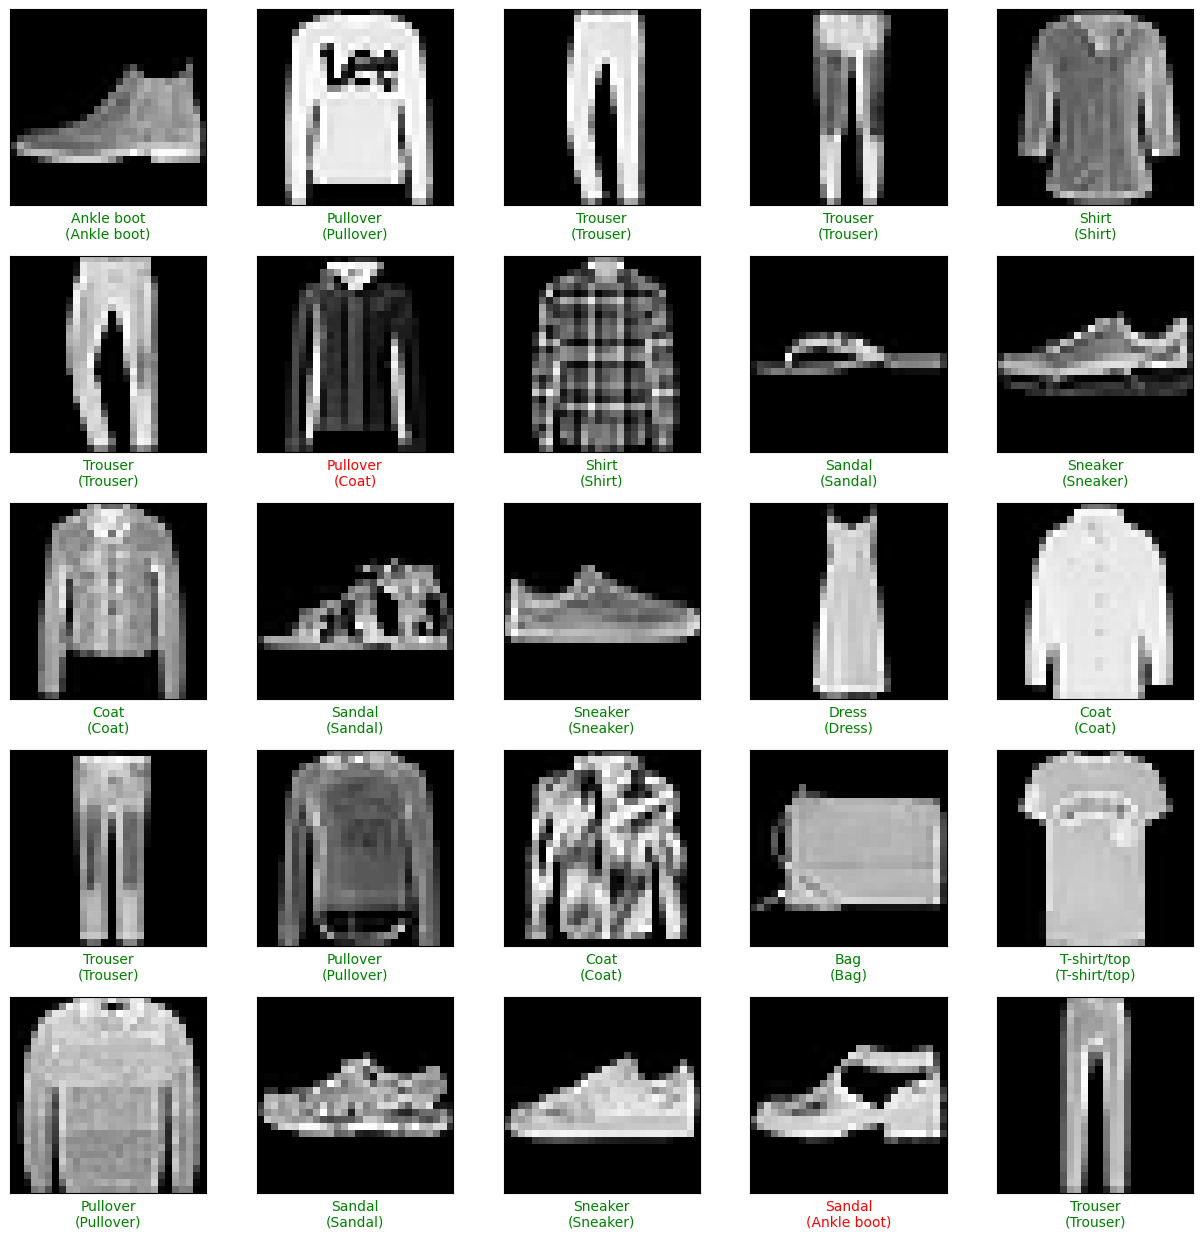

In [12]:
# --- 7. Make and Visualize Predictions ---
print("Making predictions and visualizing results...")

# Get predictions for the test set
predictions = model.predict(x_test)
# Get the class with the highest probability for each prediction
predicted_labels = np.argmax(predictions, axis=1)

# Plot a grid of test images, their predicted labels, and true labels
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols

# Adjust figure size for a 5x5 grid (e.g., 2.5 inches per image)
plt.figure(figsize=(num_cols * 2.5, num_rows * 2.5))
for i in range(num_images):
    # Use a 5x5 subplot grid
    plt.subplot(num_rows, num_cols, i + 1)

    # Plot the image
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.xticks([])
    plt.yticks([])

    # Get true and predicted labels
    true_label = y_test[i]
    predicted_label = predicted_labels[i]

    # Set color based on correctness
    color = 'green' if predicted_label == true_label else 'red'

    plt.xlabel(f"{class_names[predicted_label]}\n({class_names[true_label]})", color=color)

plt.tight_layout()
plt.show()

The convolutional neural network (CNN) was successfully trained for 20 epochs to classify clothing items from the Fashion MNIST dataset.

The model's final performance is measured quantitatively by the test accuracy and loss, which are printed to the console after evaluation. This tells us exactly what percentage of unseen images the model classified correctly.

Furthermore, the script generates two key visualizations:


*   Training History Plots: These graphs show how the model's accuracy and loss changed over time during training. By comparing the training lines to the validation lines, you can see how well the model learned and whether it started to overfit (i.e., perform worse on new data than on the data it was trained on).
*   Prediction Visualization: This grid of images provides a qualitative look at the model's performance, showing specific examples of items it identified correctly (in green) and incorrectly (in red). This helps you understand what kind of items the model struggles with.